In [1]:
import pandas as pd


In [3]:
events = pd.read_csv("../data/events.csv")
print(len(events))
events.head()

2756101


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [6]:
print(events.columns.tolist())
print(events["event"].value_counts())

['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [13]:
funnel = events.groupby('event')['visitorid'].nunique()
print(funnel)

event
addtocart        37722
transaction      11719
view           1404179
Name: visitorid, dtype: int64


In [15]:
views = funnel['view']
corz = funnel['addtocart']
buys = funnel['transaction']

In [34]:
print(f"Смотрели товары    {views:>8}")
print(f"Добавили в корзину {corz:>8}    ({corz/views:.1%} от смотревших)")
print(f"Купили             {buys:>8}    ({buys/corz:.1%} от корзины, {buys/views:.2%} сквозная)")

Смотрели товары     1404179
Добавили в корзину    37722    (2.7% от смотревших)
Купили                11719    (31.1% от корзины, 0.83% сквозная)


In [35]:
import matplotlib.pyplot as plt

In [36]:
steps = ['Просмотры','Корзина','Покупки']
values = [views,corz,buys]

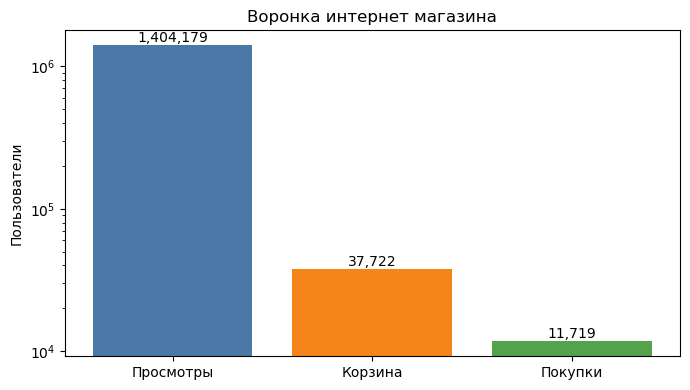

In [38]:
fig,ax = plt.subplots(figsize = (7,4))
bars = ax.bar(steps, values, color = ["#4C78A8", "#F58518", "#54A24B"])

ax.set_title('Воронка интернет магазина')
ax.set_ylabel('Пользователи')

for bar, v in zip(bars,values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,}",
            ha='center', va='bottom')

ax.set_yscale("log")    
plt.tight_layout()
plt.savefig('../data/funnel.png',dpi = 120)
plt.show()